In [13]:
!pip install torch torchvision torchaudio

# User Input Cell

In [14]:
import numpy as np

# Gravitational constant
G = 6.67430e-11

# Masses (kg)
m1 = 5.972e24  # Earth
m2 = 7.348e22  # Moon

# Initial positions (2D)
x1 = np.array([0.0, 0.0])
x2 = np.array([384400000.0, 0.0])  # ~distance Earth-Moon in meters

# Initial velocities (2D)
v1 = np.array([0.0, 0.0])
v2 = np.array([0.0, 1022.0])  # Moon's orbital speed

# Prediction time (seconds)
t_predict = 3600 * 24 * 2  # 2 days


# Data Generation Cell

In [15]:
from scipy.integrate import solve_ivp

def two_body_dynamics(t, y, m1, m2):
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    r1 = np.array([x1, y1])
    r2 = np.array([x2, y2])
    r = r2 - r1
    norm_r = np.linalg.norm(r)

    a1 = G * m2 * r / norm_r**3
    a2 = -G * m1 * r / norm_r**3

    return [vx1, vy1, vx2, vy2, a1[0], a1[1], a2[0], a2[1]]

def generate_data(num_samples=1000):
    X, Y = [], []
    for _ in range(num_samples):
        v1_rand = np.random.randn(2) * 100
        v2_rand = np.random.randn(2) * 1000
        t_rand = np.random.uniform(1000, 3600*24*3)

        y0 = [*x1, *x2, *v1_rand, *v2_rand]
        sol = solve_ivp(two_body_dynamics, [0, t_rand], y0, args=(m1, m2), t_eval=[t_rand])

        if sol.success:
            final = sol.y[:, -1]
            X.append([m1, m2, *x1, *x2, *v1_rand, *v2_rand, t_rand])
            Y.append([final[0], final[1], final[2], final[3]])  
    return np.array(X), np.array(Y)

X_train, Y_train = generate_data(1500)
X_test, Y_test = generate_data(300)


# Model Definition and Training

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_Y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
Y_train_scaled = scaler_Y.fit_transform(Y_train)
X_test_scaled = scaler_X.transform(X_test)
Y_test_scaled = scaler_Y.transform(Y_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_scaled, dtype=torch.float32)

class PositionPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 4)  # x1, y1, x2, y2
        )

    def forward(self, x):
        return self.net(x)

model = PositionPredictor()
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3000):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, Y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 0.6662
Epoch 20: Loss = 0.6391
Epoch 40: Loss = 0.6033
Epoch 60: Loss = 0.5531
Epoch 80: Loss = 0.4842
Epoch 100: Loss = 0.4064
Epoch 120: Loss = 0.3288
Epoch 140: Loss = 0.2684
Epoch 160: Loss = 0.2319
Epoch 180: Loss = 0.2064
Epoch 200: Loss = 0.1851
Epoch 220: Loss = 0.1647
Epoch 240: Loss = 0.1463
Epoch 260: Loss = 0.1305
Epoch 280: Loss = 0.1172
Epoch 300: Loss = 0.1062
Epoch 320: Loss = 0.0994
Epoch 340: Loss = 0.0945
Epoch 360: Loss = 0.0901
Epoch 380: Loss = 0.0864
Epoch 400: Loss = 0.0829
Epoch 420: Loss = 0.0801
Epoch 440: Loss = 0.0781
Epoch 460: Loss = 0.0757
Epoch 480: Loss = 0.0743
Epoch 500: Loss = 0.0729
Epoch 520: Loss = 0.0716
Epoch 540: Loss = 0.0708
Epoch 560: Loss = 0.0700
Epoch 580: Loss = 0.0692
Epoch 600: Loss = 0.0682
Epoch 620: Loss = 0.0677
Epoch 640: Loss = 0.0671
Epoch 660: Loss = 0.0670
Epoch 680: Loss = 0.0662
Epoch 700: Loss = 0.0656
Epoch 720: Loss = 0.0652
Epoch 740: Loss = 0.0648
Epoch 760: Loss = 0.0646
Epoch 780: Loss = 0.0641
Epoch 

# Evaluation

Mean Absolute Error (MAE): 5454721.50 meters


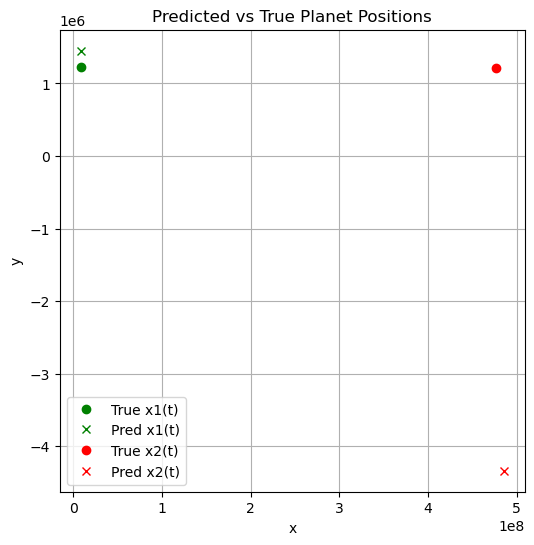

In [23]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    preds_unscaled = scaler_Y.inverse_transform(preds.numpy())
    targets_unscaled = scaler_Y.inverse_transform(Y_test_tensor.numpy())

mae = np.mean(np.abs(preds_unscaled - targets_unscaled))
print(f"Mean Absolute Error (MAE): {mae:.2f} meters")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(targets_unscaled[0][0], targets_unscaled[0][1], 'go', label='True x1(t)')
plt.plot(preds_unscaled[0][0], preds_unscaled[0][1], 'gx', label='Pred x1(t)')
plt.plot(targets_unscaled[0][2], targets_unscaled[0][3], 'ro', label='True x2(t)')
plt.plot(preds_unscaled[0][2], preds_unscaled[0][3], 'rx', label='Pred x2(t)')
plt.legend()
plt.title("Predicted vs True Planet Positions")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()
